# Basic dataset overview

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from pathlib import Path

BASE_DIR = Path.cwd().parent
file_path = BASE_DIR / "data" / "raw" / "student_lifestyle_dataset.csv"

df = pd.read_csv(file_path)
display(df.head())
df.info()
display(df.describe())
display(df.isna().sum())
display(df.duplicated().sum())
display(df.duplicated(subset=['Student_ID']).sum())
display(df.duplicated(subset=['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Stress_Level', 'Gender', 'Grades']).sum())

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   Stress_Level                     2000 non-null   str    
 7   Gender                           2000 non-null   str    
 8   Grades                           2000 non-null   float64
dtypes: float64(6), int64(1), str(2)
memory usage: 160.6 KB


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,7.789825
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.746777
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,5.600000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,7.250000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,7.780000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,8.320000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,10.000000


Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
Stress_Level                       0
Gender                             0
Grades                             0
dtype: int64

np.int64(0)

np.int64(0)

np.int64(0)

### Conclusion

- Number of rows: 2000
- Number of columns: 9
- Main numeric columns: Study_Hours_Per_Day, Extracurricular_Hours_Per_Day, Sleep_Hours_Per_Day, Social_Hours_Per_Day, Physical_Activity_Hours_Per_Day, Grades
- There are no empty (NaN) values found
- There are no duplicates indicated
- Two columns, Stress_Level and Gender, have string type, which will be treated as categorical features 

### Potential outliers check

One observation has 13 sleep hours per day, which is higher than the rest of the sample.  
This record is treated as a potential outlier and will be checked further in the analysis, but not removed for now.

Number of students with 12 hours or more of physical activity = 4


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
62,63,5.1,0.5,5.2,0.2,13.0,High,Male,7.12
171,172,5.1,0.3,6.0,0.2,12.4,Low,Male,6.75
784,785,5.1,0.3,6.3,0.2,12.1,Low,Female,6.38
1174,1175,5.3,0.3,5.9,0.2,12.3,High,Male,7.42


Metric               With outliers   Without outliers Difference      % of changes   

Mean                 4.3283          4.3120          0.0163          0.38           %
Median               4.1000          4.1000          0.0000          0.00           %
Std                  2.5141          2.4901          0.0240          0.96           %

Number of records: 2000 → 1996 (deleted: 4)


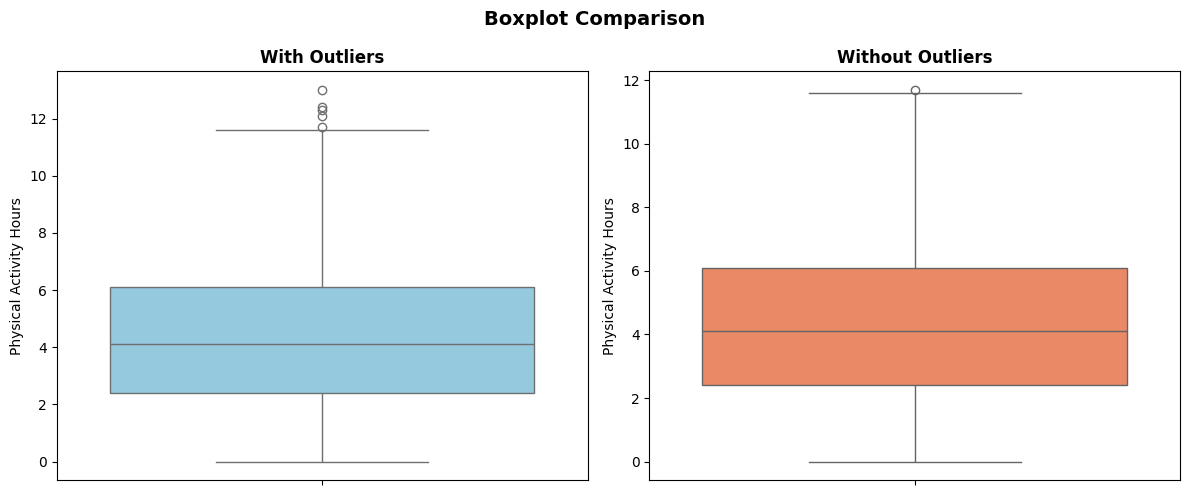


Conclusion on the impact of the outliers

- Mean changed by 0.38% from 4.33 to 4.31
- Median changed by 0.00% from 4.10 to 4.10
- Standard deviation changed by 0.96% from 2.51 to 2.49
Impact is minimal - the ourlier can be left in the data


In [72]:
outliers = df[df["Physical_Activity_Hours_Per_Day"] >= 12]
print(f"Number of students with 12 hours or more of physical activity = {len(outliers)}")
display(outliers)
col = "Physical_Activity_Hours_Per_Day"

mean_with = df[col].mean()
median_with = df[col].median()
std_with = df[col].std()

df_no_outliers = df[df[col] < 12]
mean_without = df_no_outliers[col].mean()
median_without = df_no_outliers[col].median()
std_without = df_no_outliers[col].std()

print(f"{'Metric':<20} {'With outliers':<15} {'Without outliers':<15} {'Difference':<15} {'% of changes':<15}")
print(f"\n{'Mean':<20} {mean_with:<15.4f} {mean_without:<15.4f} {mean_with - mean_without:<15.4f} {(mean_with - mean_without) / mean_without * 100:<15.2f}%")
print(f"{'Median':<20} {median_with:<15.4f} {median_without:<15.4f} {median_with - median_without:<15.4f} {(median_with - median_without) / median_without * 100:<15.2f}%")
print(f"{'Std':<20} {std_with:<15.4f} {std_without:<15.4f} {std_with - std_without:<15.4f} {(std_with - std_without) / std_without * 100:<15.2f}%")
print(f"\nNumber of records: {len(df)} → {len(df_no_outliers)} (deleted: {len(df) - len(df_no_outliers)})")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y=col, ax=axes[0], color="skyblue")
axes[0].set_title("With Outliers", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Physical Activity Hours")

sns.boxplot(data=df_no_outliers, y=col, ax=axes[1], color="coral")
axes[1].set_title("Without Outliers", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Physical Activity Hours")

plt.suptitle("Boxplot Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mean_change_pct = abs((mean_with - mean_without) / mean_without * 100)
median_change_pct = abs((median_with - median_without) / median_without * 100)
std_change_pct = abs((std_with - std_without) / std_without * 100)

print("\nConclusion on the impact of the outliers\n")

print(f"- Mean changed by {mean_change_pct:.2f}% from {mean_with:.2f} to {mean_without:.2f}")
print(f"- Median changed by {median_change_pct:.2f}% from {median_with:.2f} to {median_without:.2f}")
print(f"- Standard deviation changed by {std_change_pct:.2f}% from {std_with:.2f} to {std_without:.2f}")
if mean_change_pct < 1 and median_change_pct < 1 and std_change_pct < 1:
    print("Impact is minimal - the ourlier can be left in the data")
elif mean_change_pct < 5 and median_change_pct < 5 and std_change_pct < 5:
    print("Impact is moderate - the analysis should be conducted with and without the outliers")
else:
    print("Impact is strong - the outliers significantly distorts the picture")


### Outliers Analysis: Physical Activity >= 12 hours

**Finding:** Four students report 12 hours or more of daily physical activity

**Impact Assessment:**
- Mean changed by 0.38% (from 4.33 to 4.31)
- Median changed by 0.00% (from 4.10 to 4.10)
- Standard deviation changed by 0.96% (from 2.51 to 2.49)

**Conclusion:** 
The outliers have a minimal impact on the main statistics.

**Decision:**
The outliers are left in the dataset

# Univariate Analysis

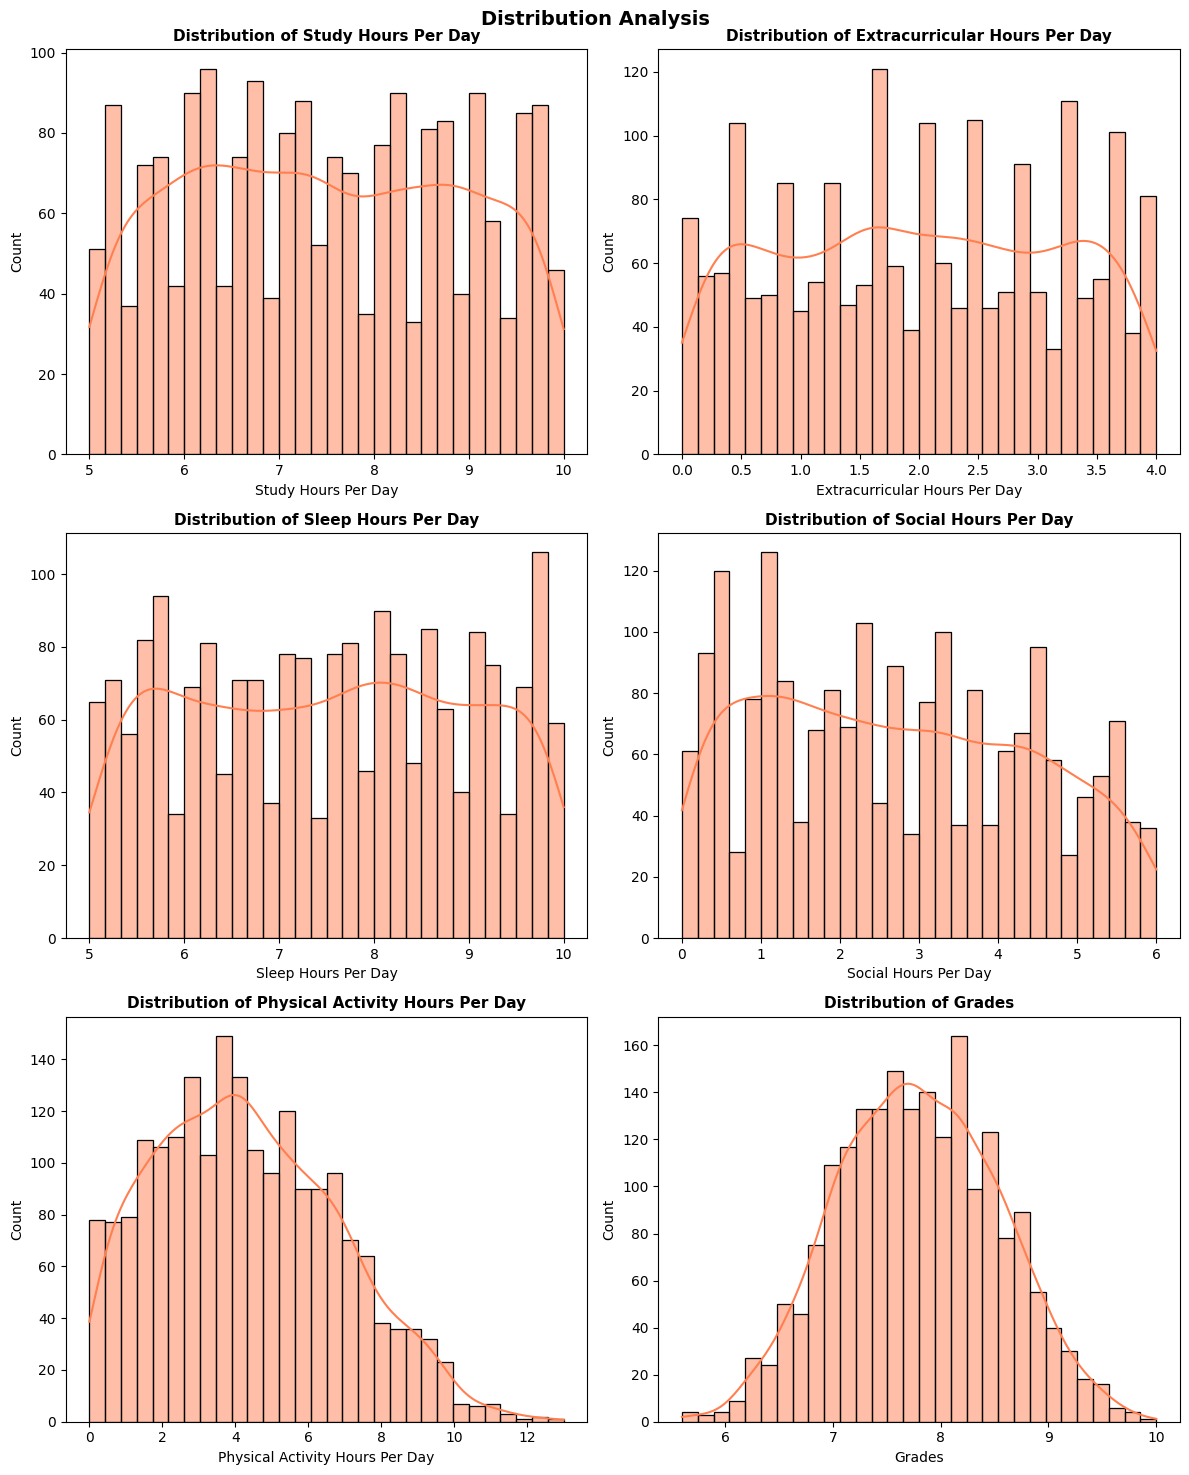

In [20]:
columns = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Grades"
]

fig, axes = plt.subplots(3, 2, figsize=(12, 15))
axes = axes.flatten()

for ax, col in zip(axes, columns):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=ax, color="coral")
    ax.set_title(f"Distribution of {col.replace('_', ' ')}", fontsize=11, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel("Count")

plt.suptitle("Distribution Analysis", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Numerical fields

### Distribution of Numerical Variables

**Study Hours Per Day**:
- Range: 5-10 hours
- Distribution: Nearly uniform
- Conclusion: No discernible mode

**Extracurricular Hours Per Day**:
- Range: 0-4 hours
- Distribution: Nearly uniform
- Conclusion: KDE is almost flat <=> distributed equally

**Sleep Hours Per Day**:
- Range: 5-10 hours
- Distribution: Nearly uniform with some spikes
- Conclusion: Noticeable spike around 9.5–10 hours, otherwise, the contribution is chaotic

**Social Hours Per Day**:
- Range: 0-6 hours
- Distribution: Slightly skewed to the right (negative skew)
- Conclusion: KDE shows a slight decline <=> more people socialize briefly

**Physical Activity Hours Per Day**:
- Range: 0-6 hours
- Distribution: Right-skewed (positive skew); peak - most people exercise about 3-4 hours per day; tail - there is a long "tail" to the right <=> a small number of people exercise very heavily (up to 12 hours), which are outliers or simply rare cases
- Conclusion: KDE shows a slight decline <=> more people socialize briefly

**Grades**:
- Range: 5.5-10
- Distribution: Normal (bell)
- Mean: ~7.5-8.0
- Conclusion: Most students have average grades

/var/folders/y9/zxqz5ct56s3177q3qysyh57m0000gn/T/ipykernel_78859/3296783276.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="rocket_r")
/var/folders/y9/zxqz5ct56s3177q3qysyh57m0000gn/T/ipykernel_78859/3296783276.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=ax, palette="rocket_r")


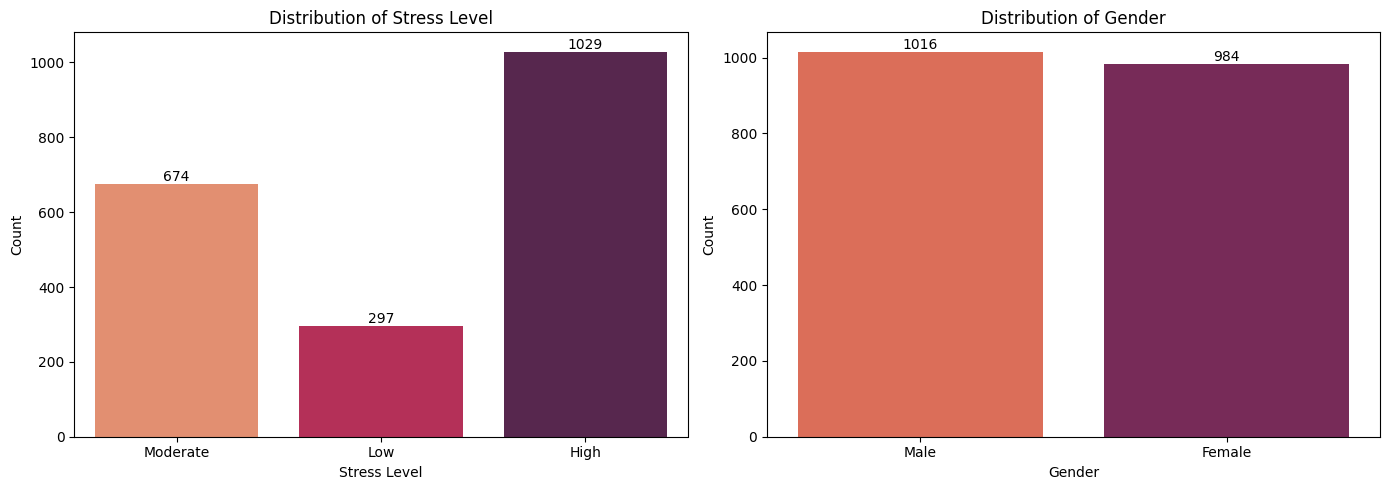

In [73]:
categorical_cols = ["Stress_Level", "Gender"]
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(14, 5))

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, ax=ax, palette="rocket_r")
    ax.set_title(f"Distribution of {col.replace('_', ' ')}", fontsize=12)
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel("Count")
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Categorical fields
### Distribution of Categorical Variables
**Stress Level**:
- Categories: Low, Moderate, High
- Distribution: Skewed toward "High" stress
- Counts: Low — 297 (~15%), Moderate — 674 (~35%), High — 1029 (~50%)
- Conclusion: More than half of students report high stress levels <=> the dataset is dominated by stressed students, which may indicate selection bias or a high-stress academic environment

**Gender**:
- Categories: Male, Female
- Distribution: Nearly uniform
- Counts: Male — 1016 (~50%), Female — 984 (~50%)
- Conclusion: Neither group is underrepresented


# Descriptive Statisctics For All Numerical Fields

DESCRIPTIVE STATISTICS FOR NUMERICAL FIELDS


,Field,Count,Mean,Median,Std Dev,Min,Max,Q1 (25%),Q3 (75%)
0,Study_Hours_Per_Day,2000,7.475800,7.40,1.423888,5.0,10.0,6.30,8.70
1,Extracurricular_Hours_Per_Day,2000,1.990100,2.00,1.155855,0.0,4.0,1.00,3.00
2,Sleep_Hours_Per_Day,2000,7.501250,7.50,1.460949,5.0,10.0,6.20,8.80
3,Social_Hours_Per_Day,2000,2.704550,2.60,1.688514,0.0,6.0,1.20,4.10
4,Physical_Activity_Hours_Per_Day,2000,4.328300,4.10,2.514110,0.0,13.0,2.40,6.10
5,Grades,2000,7.789825,7.78,0.746777,5.6,10.0,7.25,8.32


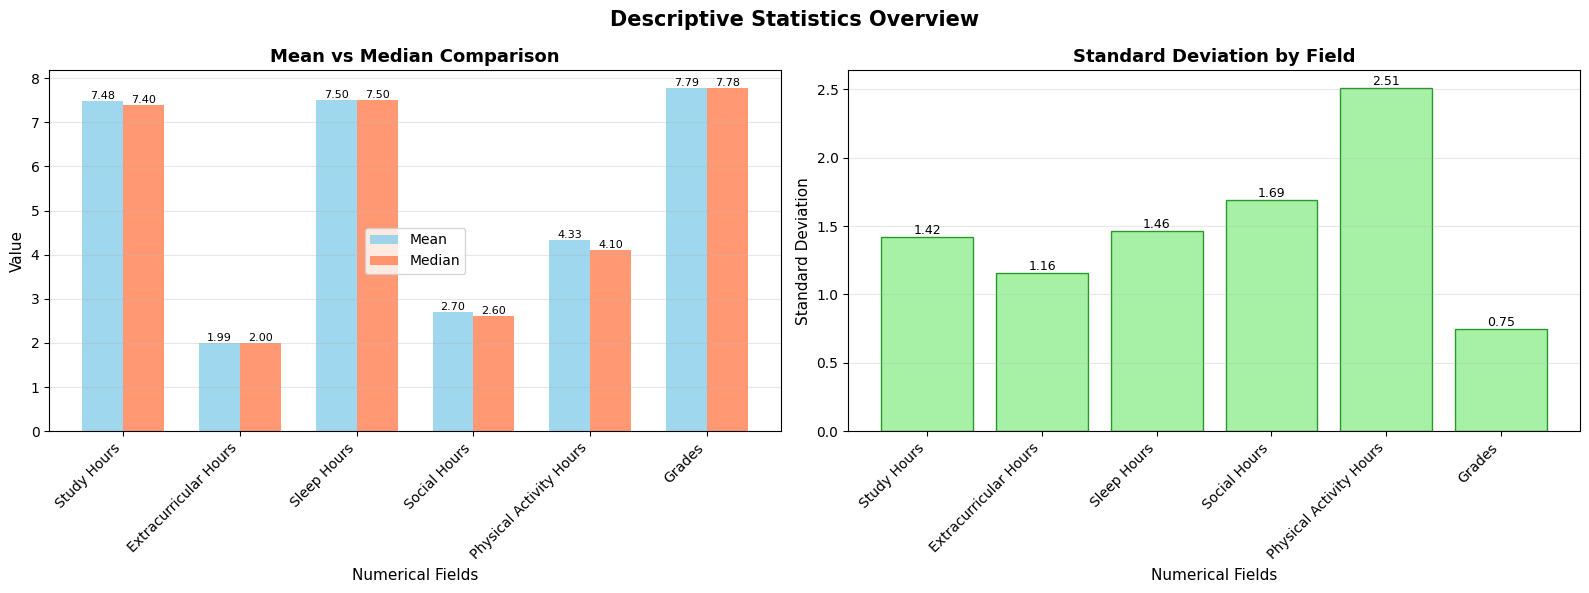

DETAILED STATISTICAL SUMMARY

Study_Hours_Per_Day:
  Count:              2000
  Mean:               7.476
  Median:             7.400
  Standard Deviation: 1.424
  Min:                5.000
  Q1 (25th):          6.300
  Q3 (75th):          8.700
  Max:                10.000
  Range:              5.000
  IQR:                2.400

Extracurricular_Hours_Per_Day:
  Count:              2000
  Mean:               1.990
  Median:             2.000
  Standard Deviation: 1.156
  Min:                0.000
  Q1 (25th):          1.000
  Q3 (75th):          3.000
  Max:                4.000
  Range:              4.000
  IQR:                2.000

Sleep_Hours_Per_Day:
  Count:              2000
  Mean:               7.501
  Median:             7.500
  Standard Deviation: 1.461
  Min:                5.000
  Q1 (25th):          6.200
  Q3 (75th):          8.800
  Max:                10.000
  Range:              5.000
  IQR:                2.600

Social_Hours_Per_Day:
  Count:              2000
  Mean

In [3]:
# Block 1: Creating a statistics pivot table

stats_data = []

numeric_cols = [
    "Study_Hours_Per_Day",
    "Extracurricular_Hours_Per_Day",
    "Sleep_Hours_Per_Day",
    "Social_Hours_Per_Day",
    "Physical_Activity_Hours_Per_Day",
    "Grades"
]

for col in numeric_cols:
    stats_data.append({
        'Field': col,
        'Count': df[col].count(),
        'Mean': df[col].mean(),
        'Median': df[col].median(),
        'Std Dev': df[col].std(),
        'Min': df[col].min(),
        'Max': df[col].max(),
        'Q1 (25%)': df[col].quantile(0.25),
        'Q3 (75%)': df[col].quantile(0.75)
    })

stats_df = pd.DataFrame(stats_data)

print("DESCRIPTIVE STATISTICS FOR NUMERICAL FIELDS")
display(stats_df)





# Block 2: Visualization of mean vs median

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x_pos = np.arange(len(numeric_cols))
width = 0.35

means = [df[col].mean() for col in numeric_cols]
medians = [df[col].median() for col in numeric_cols]

bars1 = axes[0].bar(x_pos - width/2, means, width, label='Mean', color='skyblue', alpha=0.8)
bars2 = axes[0].bar(x_pos + width/2, medians, width, label='Median', color='coral', alpha=0.8)

axes[0].set_xlabel('Numerical Fields', fontsize=11)
axes[0].set_ylabel('Value', fontsize=11)
axes[0].set_title('Mean vs Median Comparison', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([col.replace('_Per_Day', '').replace('_', ' ') for col in numeric_cols], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

stds = [df[col].std() for col in numeric_cols]
bars3 = axes[1].bar(x_pos, stds, color='lightgreen', alpha=0.8, edgecolor='green')

axes[1].set_xlabel('Numerical Fields', fontsize=11)
axes[1].set_ylabel('Standard Deviation', fontsize=11)
axes[1].set_title('Standard Deviation by Field', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([col.replace('_Per_Day', '').replace('_', ' ') for col in numeric_cols], rotation=45, ha='right')
axes[1].grid(True, axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Descriptive Statistics Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()





# Block 3: Detailed table with formatting

print("DETAILED STATISTICAL SUMMARY")

for idx, row in stats_df.iterrows():
    print(f"\n{row['Field']}:")
    print(f"  Count:              {row['Count']:.0f}")
    print(f"  Mean:               {row['Mean']:.3f}")
    print(f"  Median:             {row['Median']:.3f}")
    print(f"  Standard Deviation: {row['Std Dev']:.3f}")
    print(f"  Min:                {row['Min']:.3f}")
    print(f"  Q1 (25th):          {row['Q1 (25%)']:.3f}")
    print(f"  Q3 (75th):          {row['Q3 (75%)']:.3f}")
    print(f"  Max:                {row['Max']:.3f}")
    print(f"  Range:              {row['Max'] - row['Min']:.3f}")
    print(f"  IQR:                {row['Q3 (75%)'] - row['Q1 (25%)']:.3f}")





# Block 4: Distribution symmetry analysis

print("DISTRIBUTION SYMMETRY ANALYSIS (Mean vs Median)")

for idx, row in stats_df.iterrows():
    diff = row['Mean'] - row['Median']
    diff_pct = (diff / row['Median']) * 100 if row['Median'] != 0 else 0
    
    if abs(diff_pct) < 5:
        symmetry = "Symmetric (normal-like)"
    elif diff_pct > 5:
        symmetry = "Right-skewed (mean > median)"
    else:
        symmetry = "Left-skewed (mean < median)"
    
    print(f"\n{row['Field']}:")
    print(f"  Mean - Median = {diff:+.3f} ({diff_pct:+.2f}%)")
    print(f"  Distribution: {symmetry}")





# Block 5: Export to CSV

stats_df.to_csv('../data/processed/descriptive_statistics.csv', index=False)
print("\nDescriptive statistics saved to '../data/processed/descriptive_statistics.csv'")

## Descriptive Statistics

### Summary Table

| Field | Count | Mean | Median | Std Dev | Min | Max | Q1 | Q3 |
|-------|-------|------|--------|---------|-----|-----|----|----|
| Study Hours Per Day | 2000 | 7.476 | 7.400 | 1.424 | 5.000 | 10.000 | 6.300 | 8.700 |
| Extracurricular Hours Per Day | 2000 | 1.990 | 2.000 | 1.156 | 0.000 | 4.000 | 1.000 | 3.000 |
| Sleep Hours Per Day | 2000 | 7.501 | 7.500 | 1.461 | 5.000 | 10.000 | 6.200 | 8.800 |
| Social Hours Per Day | 2000 | 2.705 | 2.600 | 1.689 | 0.000 | 6.000 | 1.200 | 4.100 |
| Physical Activity Hours Per Day | 2000 | 4.328 | 4.100 | 2.514 | 0.000 | 13.000 | 2.400 | 6.100 |
| Grades | 2000 | 7.790 | 7.780 | 0.747 | 5.600 | 10.000 | 7.250 | 8.320 |

### Key Findings

**1. Central Tendency:**
- **Study Hours**: Mean = 7.48, Median = 7.40 → Nearly symmetric distribution
- **Sleep Hours**: Mean = 7.50, Median = 7.50 → Perfectly symmetric
- **Grades**: Mean = 7.79, Median = 7.78 → Normal distribution (as expected)

**2. Variability (Standard Deviation):**
- **Highest variability**: Physical Activity (σ = 2.51) — wide range from 0 to 13 hours
- **Lowest variability**: Grades (σ = 0.75) — most students cluster around 7.5-8.0
- **Moderate variability**: Study Hours (σ = 1.42), Sleep Hours (σ = 1.46)

**3. Distribution Symmetry:**
- Most fields show symmetric distributions (mean ≈ median)
- Physical Activity shows slight right-skew (mean > median) due to outliers (13 hours)

**4. Range Analysis:**
- **Widest range**: Physical Activity (0-13 hours, IQR = 3.7)
- **Narrowest range**: Extracurricular (0-4 hours, IQR = 2.0)
- **Grades**: Concentrated in 5.6-10 range (IQR = 1.07)

### Interpretation

The descriptive statistics reveal that:
1. Students spend approximately **7.5 hours studying** and **7.5 hours sleeping** per day
2. **Physical activity** shows the highest variability, suggesting diverse lifestyle patterns
3. **Grades** follow a normal distribution centered around 7.8, with low variability
4. The dataset appears well-balanced with no extreme skewness in most variables